### seaborn.PairGrid

`PairGrid` is a subplot grid for plotting **pairwise** relationships in a dataset.<br/>

It creates a grid of multiple axes where we can use different axes-level plotting functions for
bivariate plots in the **upper** and **lower triangles**.<br/>
Also, the **diagonal** can be used to show the **marginal distribution** of each variable.

<pre style="font-family:'Courier New';font-size:1.0em;">
<span style="color:orange;font-weight:600;">sns</span>.<span style="color:darkblue;font-weight:600;">PairGrid</span>(
    data,       # DataFrame where each column is a variable & each row an observation.
    hue,        # the name of a column to map plot aspects to different colors.
    vars,       # list of columns to use; otherwise every numeric column is used.
    x_vars,     # lists of columns to use separately for the rows and
    y_vars,     # columns of the figure; i.e. to make a non-square plot.
    hue_order   # list with the order of the levels of the hue variable in the palette.
    palette,    # Set of colors for mapping the `hue` variable.
    hue_kws,    # dict with keyword arguments to let other plot attributes vary across levels of the hue variable.
    corner,     # bool; True means don't add axes to the upper triangle of the grid.
    height,     # height(in inches) of each facet.
    aspect,     # aspect * height = width of each facet.
    layout_pad, # padding between axes.
    despine,    # Removes top and right spines.
    dropna,     # Drop missing values, before plotting.
)
</pre>

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Allowed values: white, whitegrid, dark, darkgrid
sns.set_style("darkgrid")

### Examples
#### Calling the constructor

In [17]:
penguins = sns.load_dataset("penguins")
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


This just creates an empty grid of subplots with each row and column corresponding to
a **numeric variable** in the dataset.<br/>
`species`, `island` and `sex` are categorical variables so they are not plotted.

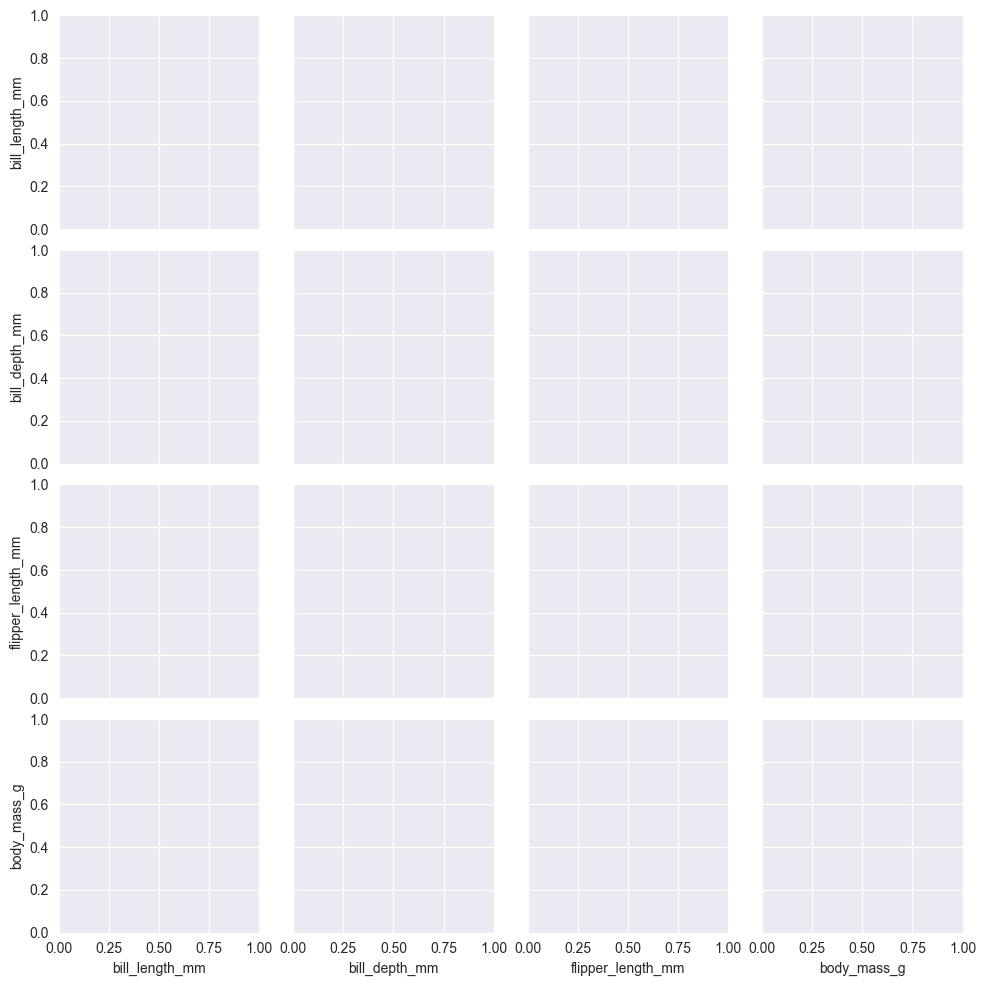

In [18]:
g = sns.PairGrid(penguins)

Passing a bivariate function to `PairGrid.map()` wil draw a bivariate plot on every axes:

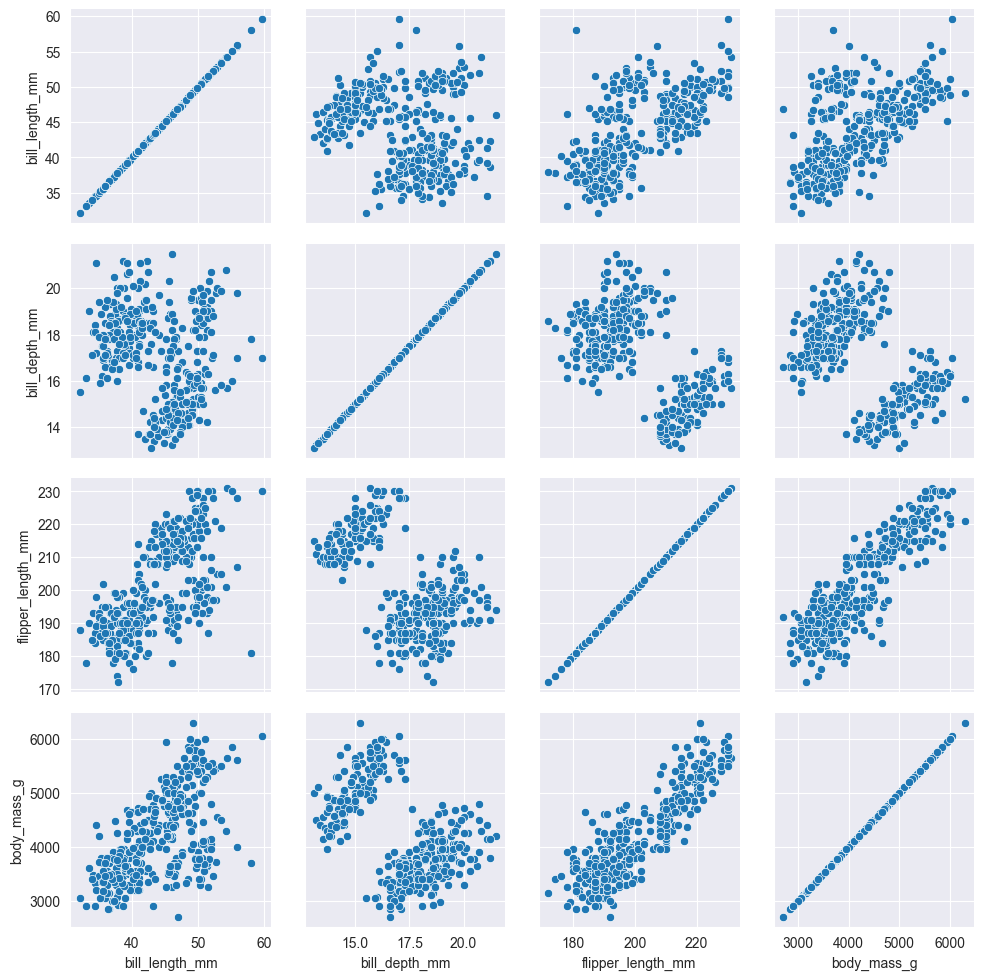

In [21]:
g = sns.PairGrid(penguins)
g.map(sns.scatterplot)

plt.show()

Use separate functions to `map_diag()` and `map_offdiag()` to show each variable's **marginal distribution** on the diagonal.

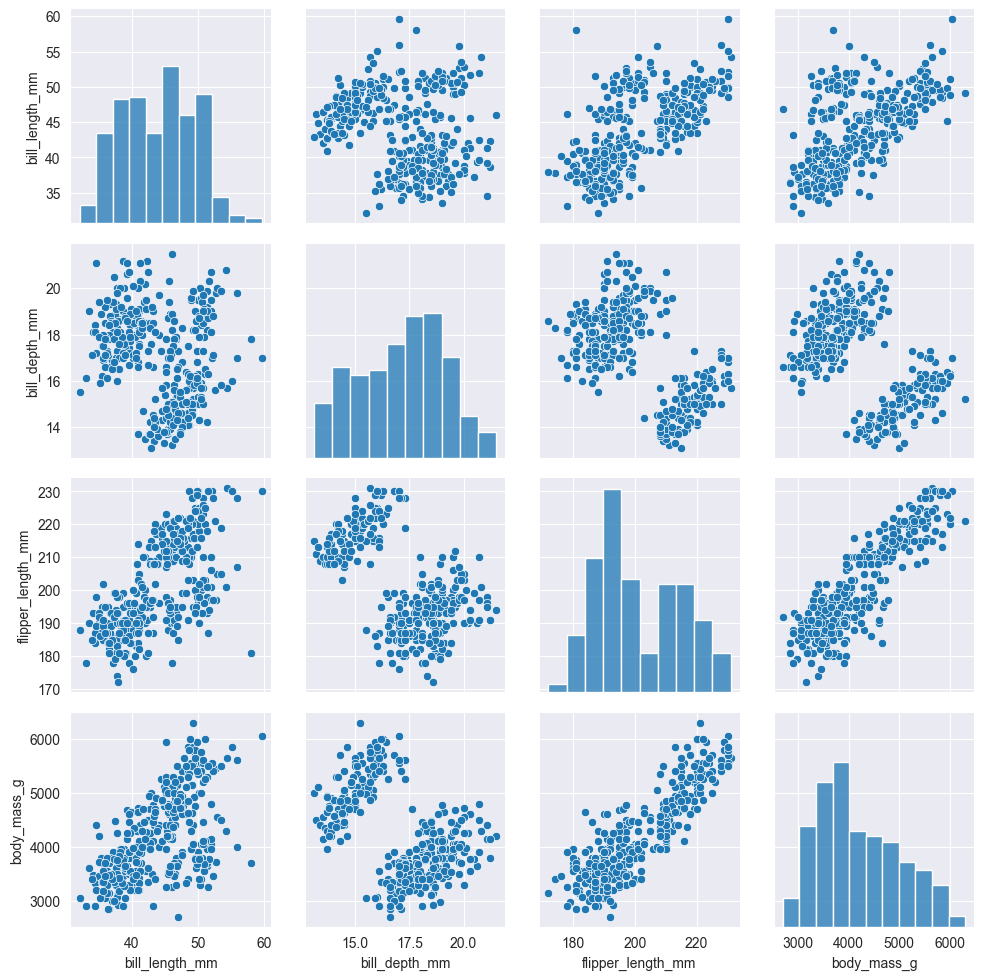

In [23]:
g = sns.PairGrid(penguins)
g.map_diag(sns.histplot)  # plot a histogram on each diagonal subplot
g.map_offdiag(sns.scatterplot)  # plot a scatter diagram on the off-diagonal subplots

Use different functions on the **upper** and **lower triangles** of the plot:

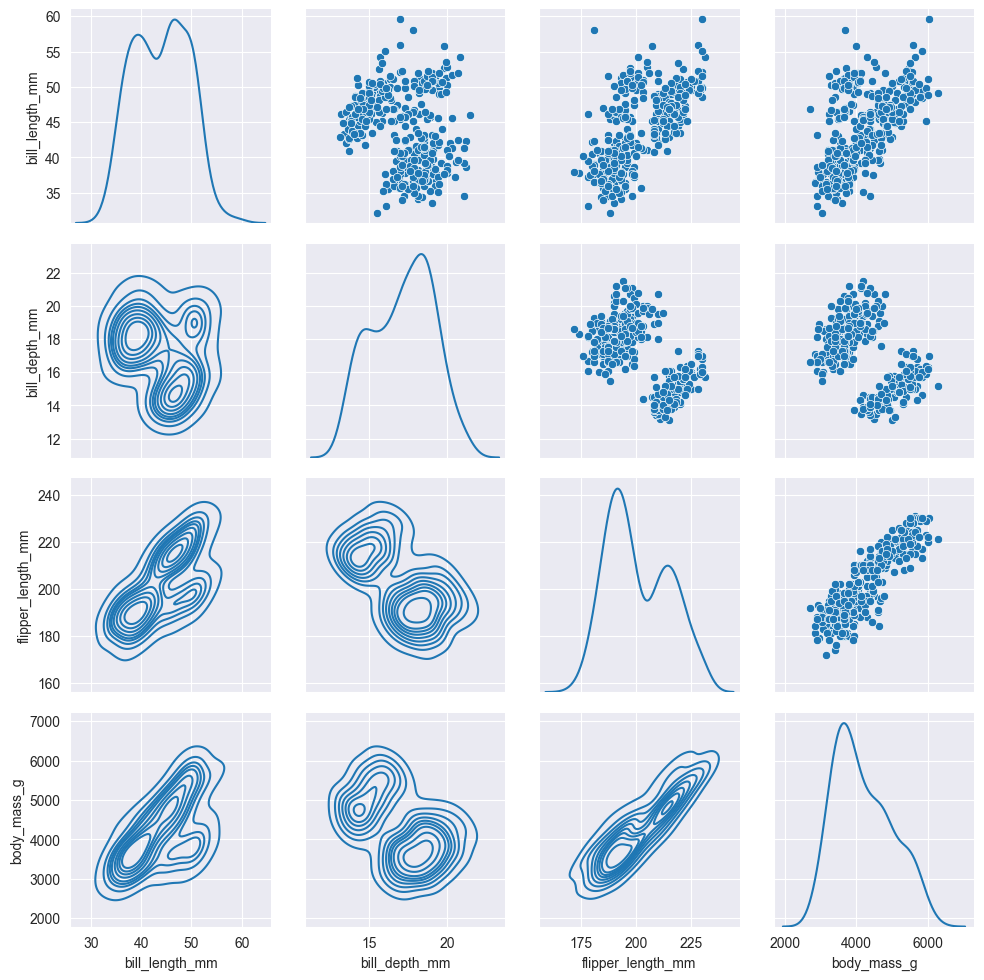

In [24]:
g = sns.PairGrid(penguins, diag_sharey=False)
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.kdeplot)

plt.show()

To avoid the redundancy altogether (bypass the upper triangle):

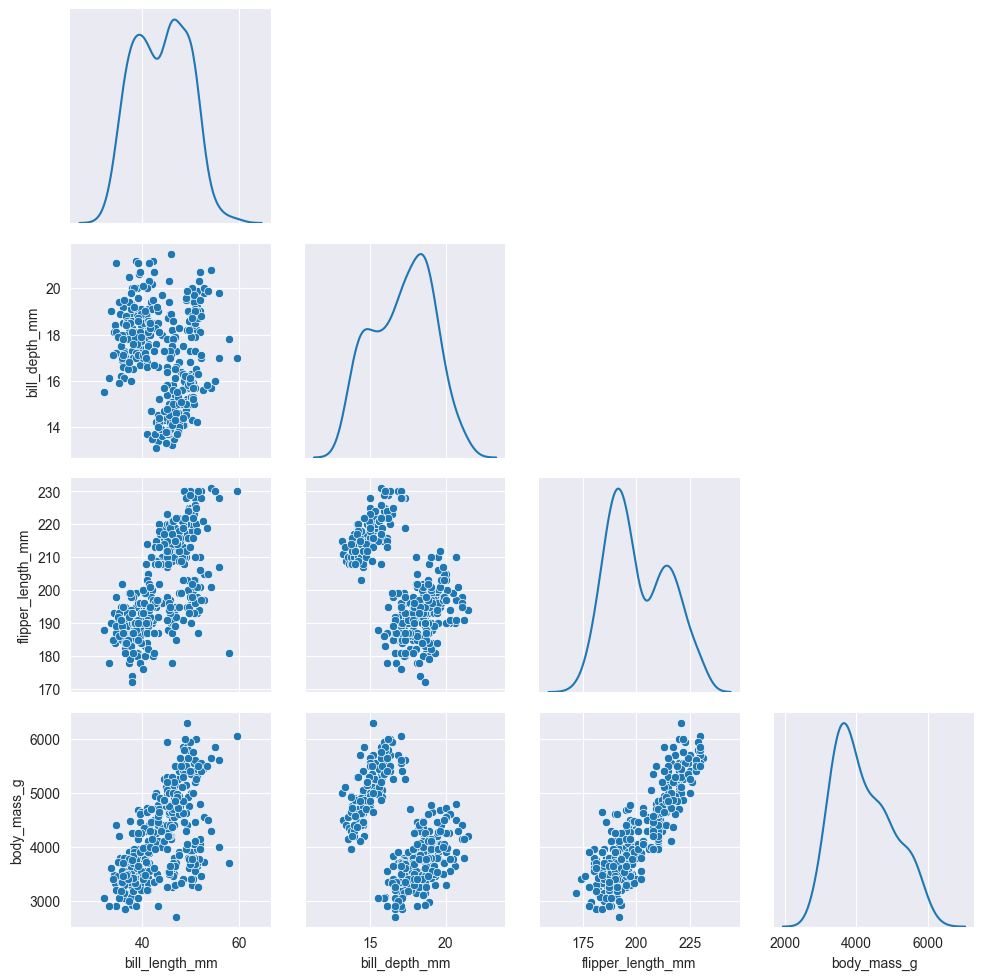

In [25]:
g = sns.PairGrid(penguins, diag_sharey=False, corner=True)
g.map_lower(sns.scatterplot)
g.map_diag(sns.kdeplot)

plt.show()

Use `species`, a categorical variable, to map plot aspects to different colors

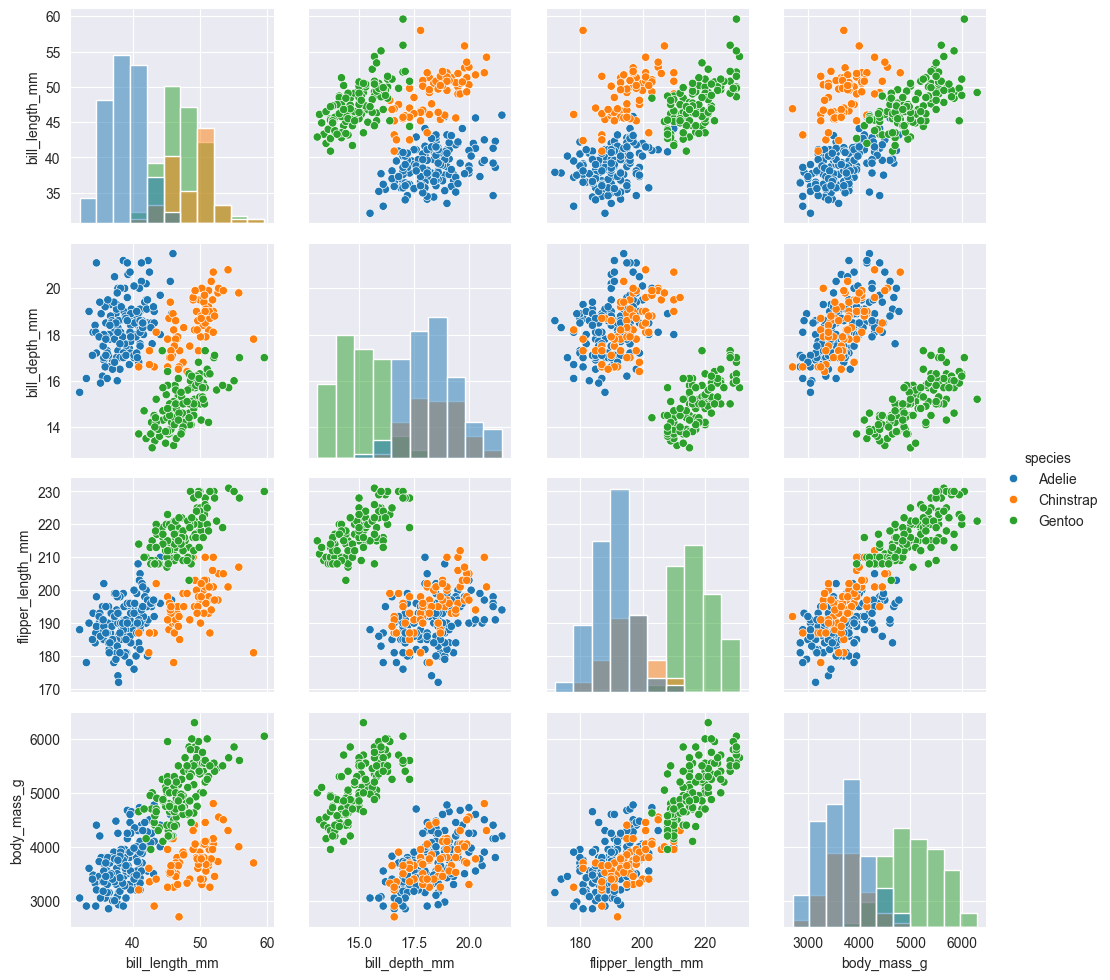

In [29]:
g = sns.PairGrid(penguins, hue="species")
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()

We can also pass `matplotlib` functions. In this case a **groupby** is performed and a separate plot is drawn for each level.

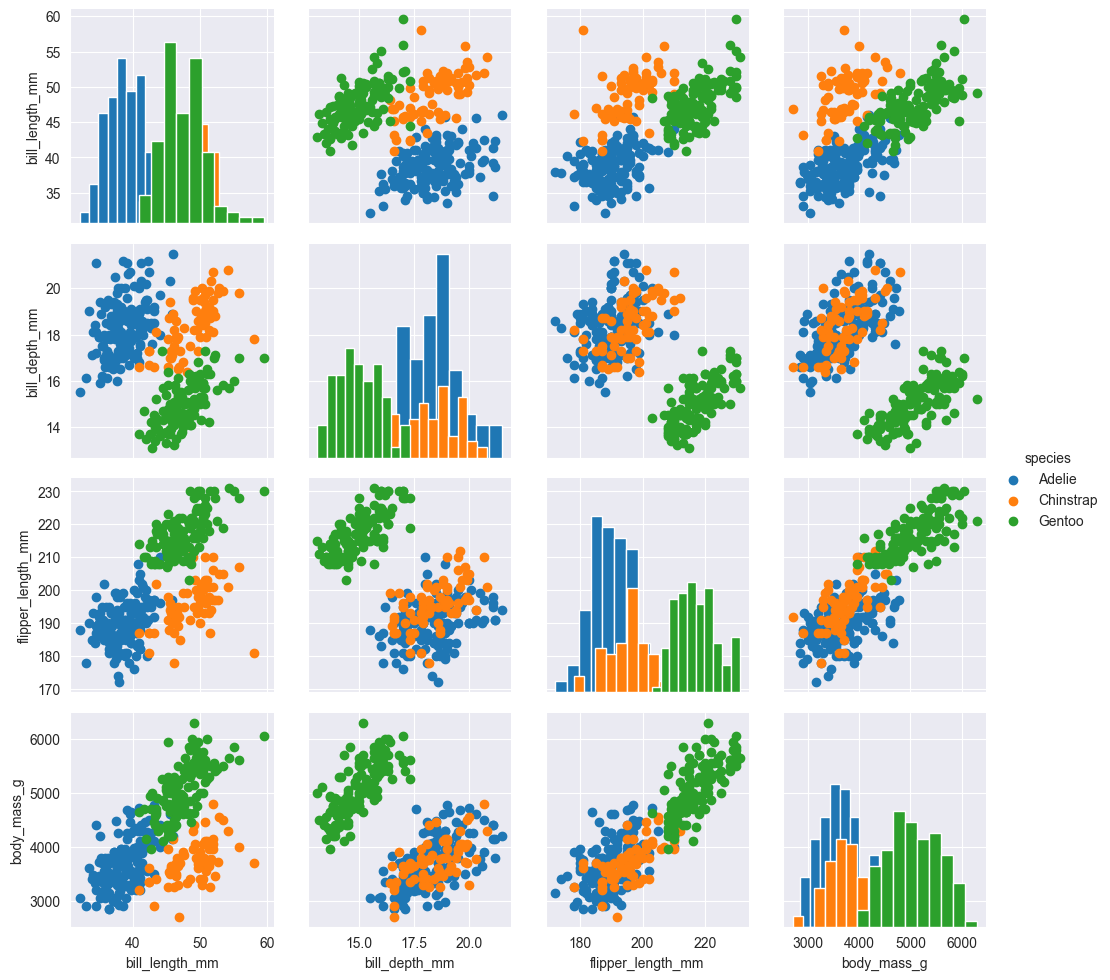

In [30]:
g = sns.PairGrid(penguins, hue="species")
g.map_diag(plt.hist)
g.map_offdiag(plt.scatter)
g.add_legend()

Additional **semantic variables** can be assigned, by passing data vectors directly while mapping the function:

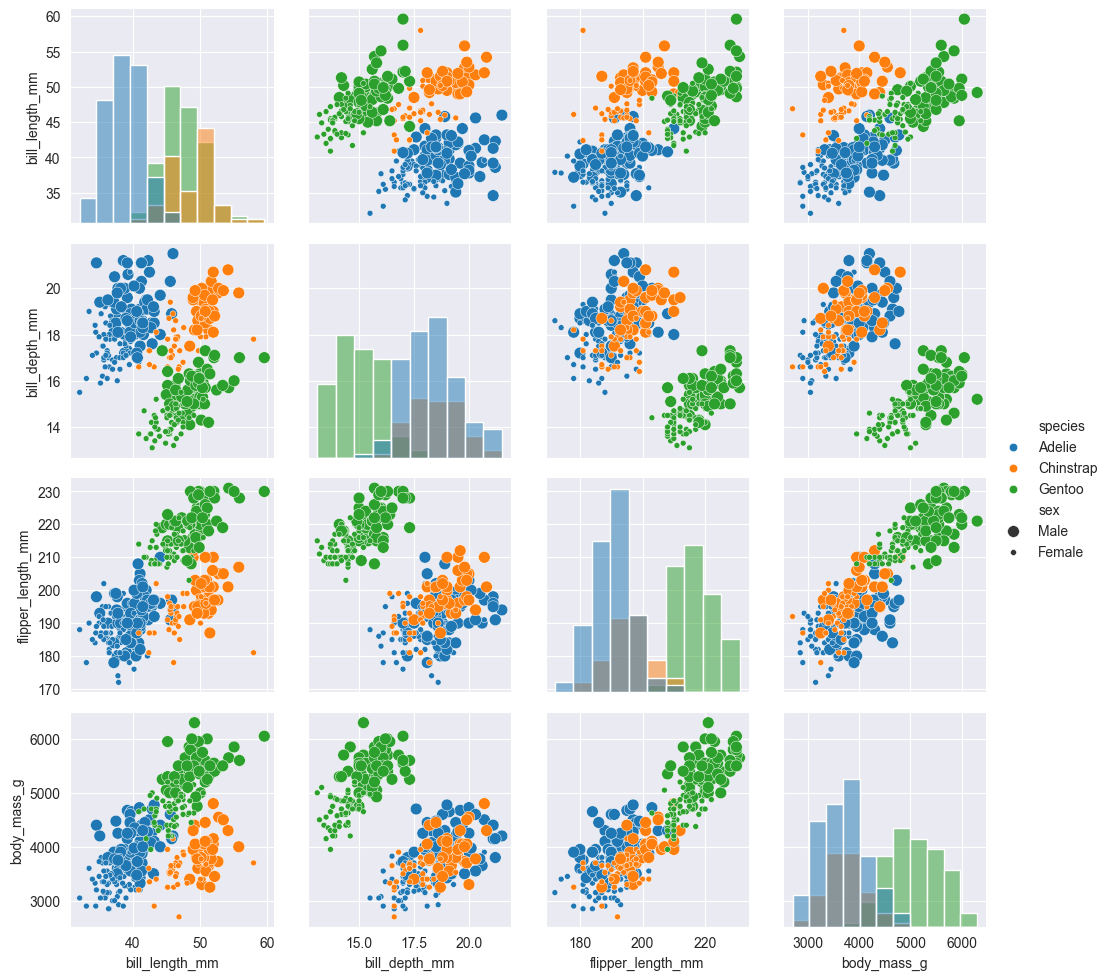

In [35]:
g = sns.PairGrid(penguins, hue="species")
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot, size=penguins["sex"])
g.add_legend(title="", adjust_subtitles=True)

If the `hue` variable is numeric, it will be excluded by default from the list of variables shown:

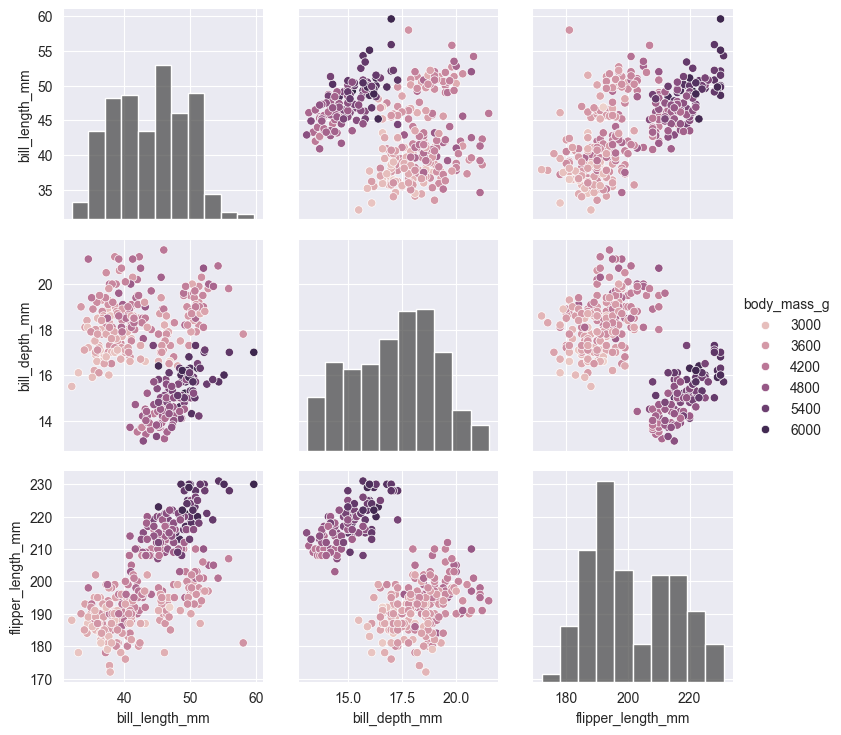

In [39]:
g = sns.PairGrid(penguins, hue="body_mass_g")
g.map_diag(sns.histplot, hue=None, color=".3")
g.map_offdiag(sns.scatterplot)
g.add_legend()

Control what variables to use:

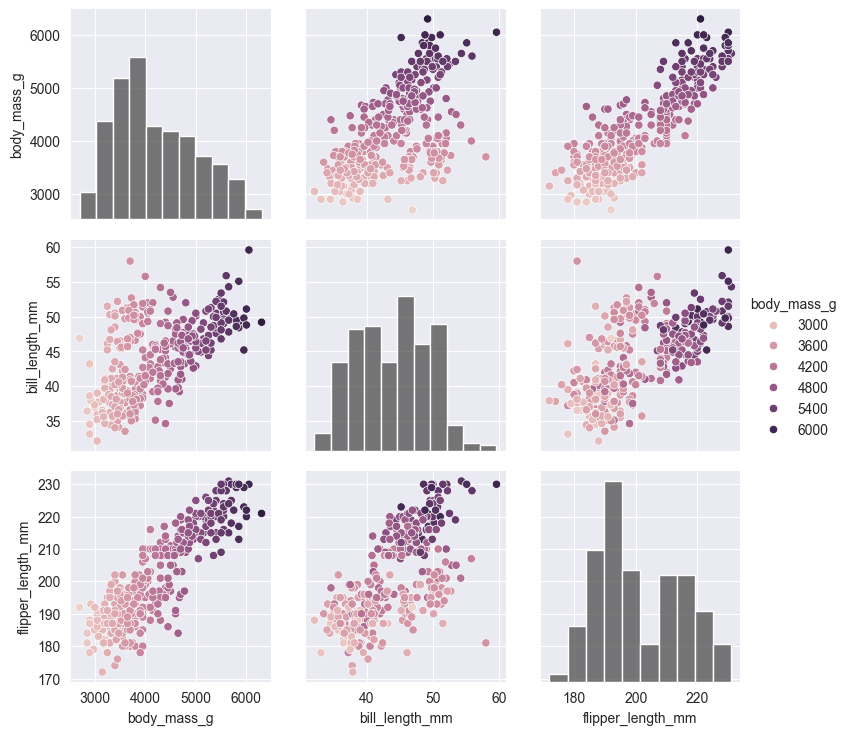

In [40]:
variables = ["body_mass_g", "bill_length_mm", "flipper_length_mm"]
g = sns.PairGrid(penguins, hue="body_mass_g", vars=variables)
g.map_diag(sns.histplot, hue=None, color=".3")
g.map_offdiag(sns.scatterplot)
g.add_legend()

No need to have a square plot. We can declare what variables to use as rows and columns:

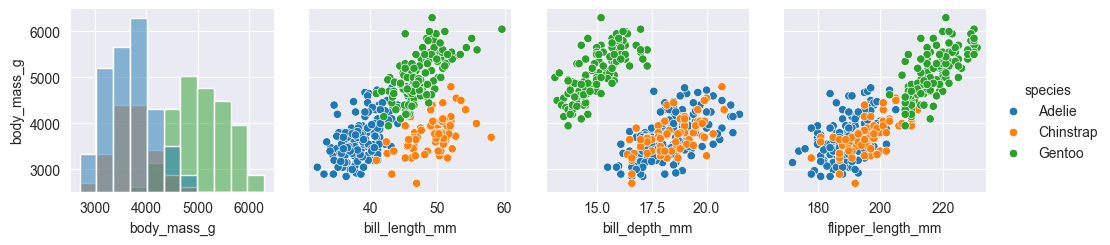

In [43]:
x_vars = ["body_mass_g", "bill_length_mm", "bill_depth_mm", "flipper_length_mm"]
y_vars = ["body_mass_g"]

g = sns.PairGrid(penguins, hue="species", x_vars=x_vars, y_vars=y_vars)
g.map_diag(sns.histplot, color=".3")
g.map_offdiag(sns.scatterplot)
g.add_legend()

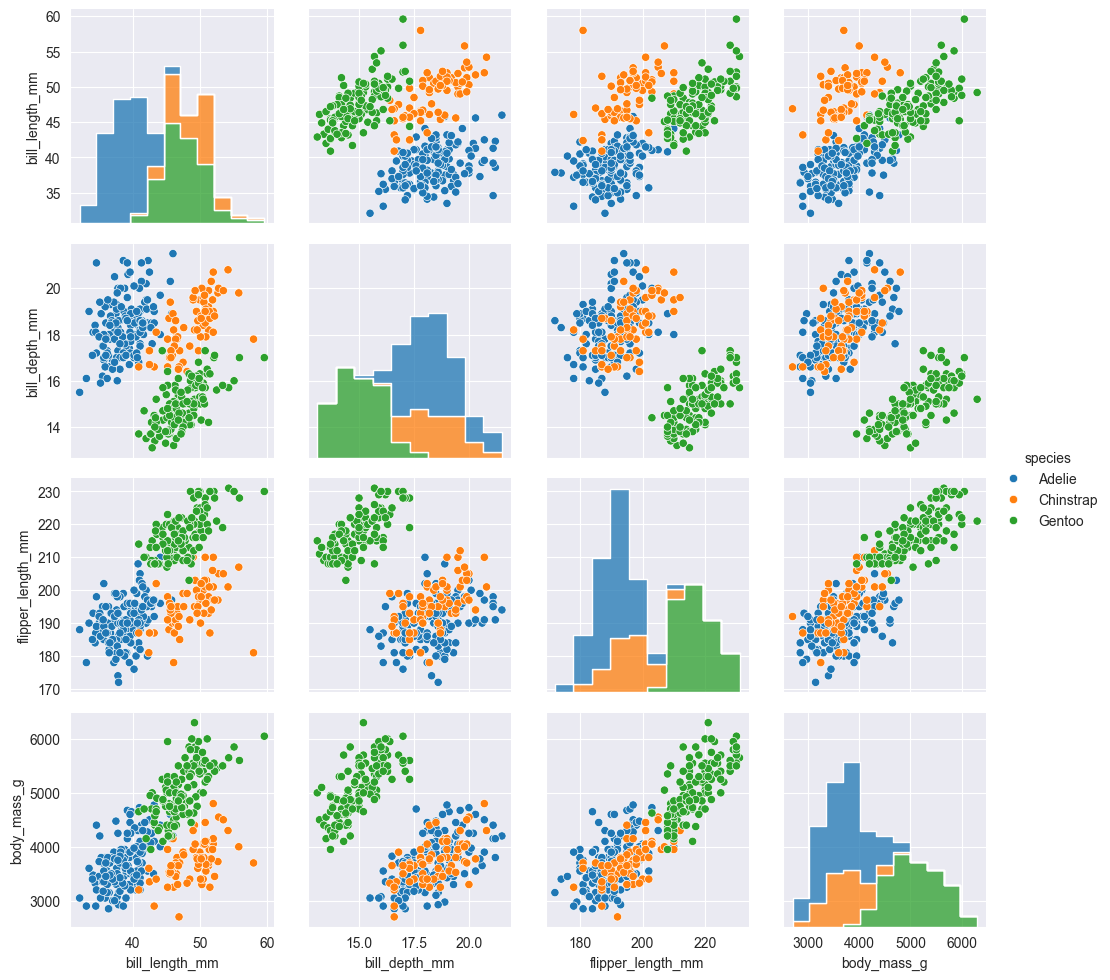

In [45]:
g = sns.PairGrid(penguins, hue="species")
g.map_diag(sns.histplot, multiple="stack", element="step")
g.map_offdiag(sns.scatterplot)
g.add_legend()